# Bonus - Using Weights from A Pretrained Model

This notebook is the bonus content for you to try it out after the class. Don't feel obligated to finish it during the session if there is not enough time.  

With the varaities of neural network architechtures and the large amount of researches happened in the space, the common case is that you don't need to deisgn the entire network architechture for your project. Knowing the data and tasks you have, it is very likely that you can find an existing model and make some changes to adapt to your project.

In [3]:
# add wd in script
!cd /scratch/vp91/zxw900/applied_ml/applied_machine_learning

In [6]:
!which python

/scratch/vp91/applied_ml_venv/bin/python


In [5]:
import numpy as np
import seaborn as sns

import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
import torch.nn.functional as F 
from torch import nn,optim
from torchvision import transforms as T,datasets,models
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from collections import OrderedDict
from tqdm import tqdm
#pd.options.plotting.backend = "plotly"

# Loading Dataset and Applying Transforms

In [ ]:
data_dir = "/scratch/vp91/zxw900/applied_ml/data/chest_xray"
TEST = 'test'
TRAIN = 'train'
VAL ='val'

In [21]:
def data_transforms(phase = None):
    
    if phase == TRAIN:

        data_T = T.Compose([
            
                T.Resize(size = (256,256)),
                T.RandomRotation(degrees = (-20,+20)),
                T.CenterCrop(size=224),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
        ])
    
    elif phase == TEST or phase == VAL:

        data_T = T.Compose([

                T.Resize(size = (224,224)),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
        ])
        
    return data_T

In [22]:
trainset = datasets.ImageFolder(os.path.join(data_dir, TRAIN),transform = data_transforms(TRAIN))
testset = datasets.ImageFolder(os.path.join(data_dir, TEST),transform = data_transforms(TEST))
validset = datasets.ImageFolder(os.path.join(data_dir, VAL),transform = data_transforms(VAL))

In [23]:
class_names = trainset.classes
print(class_names)
print(trainset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


# Loading Dataset into batches

In [30]:
trainloader = DataLoader(trainset,batch_size = 16,shuffle = True)
validloader = DataLoader(validset,batch_size = 8,shuffle = True)
testloader = DataLoader(testset,batch_size = 8,shuffle = True)

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Fine-Tuning VGG-16

In [ ]:
# you can download the pretrained model weights from here: https://download.pytorch.org/models/vgg16-397923af.pth
model = models.vgg16()
# change the path to where you store the pretrained model weights
model.load_state_dict(torch.load("../input/pretrained-model-weights-pytorch/vgg16-397923af.pth"))

<All keys matched successfully>

We take advantage of the pretrained weights of VGG-16, and modify only the layers of classification at the end. 

In [16]:
for param in model.parameters():
    param.requires_grad = False




classifier = nn.Sequential(OrderedDict([('fc1', nn.Linear(25088, 4096)),
                                         ('relu', nn.ReLU()),
                                         ('dropout',nn.Dropout(0.3)),
                                         ('fc2', nn.Linear(4096, 4096)),
                                         ('relu', nn.ReLU()),
                                         ('drop', nn.Dropout(0.3)),
                                         ('fc3', nn.Linear(4096, 2)), 
                                         ('output', nn.LogSoftmax(dim = 1))]))

model.classifier = classifier
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

# Training Model

In [17]:
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)
schedular = optim.lr_scheduler.ReduceLROnPlateau(optimizer,factor = 0.1,patience = 5)
epochs = 15
valid_loss_min = np.Inf

In [18]:
def accuracy(y_pred,y_true):
    y_pred = torch.exp(y_pred)
    top_p,top_class = y_pred.topk(1,dim = 1)
    equals = top_class == y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))

In [19]:
for i in range(epochs):
    
    train_loss = 0.0
    valid_loss = 0.0
    train_acc = 0.0
    valid_acc = 0.0 
    
    
    model.train()
    
    for images,labels in tqdm(trainloader):
        
        images = images.to(device)
        labels = labels.to(device)
        
        ps = model(images)
        loss = criterion(ps,labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_acc += accuracy(ps,labels)
        train_loss += loss.item()
        
    avg_train_acc = train_acc / len(trainloader)
    avg_train_loss = train_loss / len(trainloader)
        
    model.eval()
    with torch.no_grad():
        
        for images,labels in tqdm(validloader):
            
            images = images.to(device)
            labels = labels.to(device)
            
            ps = model(images)
            loss = criterion(ps,labels)
            
            valid_acc += accuracy(ps,labels)
            valid_loss += loss.item()
            
            
        avg_valid_acc = valid_acc / len(validloader)
        avg_valid_loss = valid_loss / len(validloader)
        
        schedular.step(avg_valid_loss)
        
        if avg_valid_loss <= valid_loss_min:
            print('Validation loss decreased ({:.6f} --> {:.6f}).   Saving model ...'.format(valid_loss_min,avg_valid_loss))
            torch.save({
                'epoch' : i,
                'model_state_dict' : model.state_dict(),
                'optimizer_state_dict' : optimizer.state_dict(),
                'valid_loss_min' : avg_valid_loss
            },'Pneumonia_model.pt')
            
            valid_loss_min = avg_valid_loss
            
            
    print("Epoch : {} Train Loss : {:.6f} Train Acc : {:.6f}".format(i+1,avg_train_loss,avg_train_acc))
    print("Epoch : {} Valid Loss : {:.6f} Valid Acc : {:.6f}".format(i+1,avg_valid_loss,avg_valid_acc))

100%|██████████| 2/2 [00:00<00:00,  6.26it/s]


Validation loss decreased (inf --> 0.051571).   Saving model ...


  0%|          | 0/326 [00:00<?, ?it/s]

Epoch : 1 Train Loss : 0.479796 Train Acc : 0.930406
Epoch : 1 Valid Loss : 0.051571 Valid Acc : 1.000000


100%|██████████| 2/2 [00:00<00:00,  6.41it/s]


...

Epoch : 13 Train Loss : 0.053100 Train Acc : 0.977761
Epoch : 13 Valid Loss : 0.404031 Valid Acc : 0.875000


  0%|          | 0/326 [00:00<?, ?it/s]

Epoch : 14 Train Loss : 0.054805 Train Acc : 0.979294
Epoch : 14 Valid Loss : 0.543267 Valid Acc : 0.875000


100%|██████████| 2/2 [00:00<00:00,  4.45it/s]

Epoch : 15 Train Loss : 0.050240 Train Acc : 0.981787
Epoch : 15 Valid Loss : 0.498102 Valid Acc : 0.875000


# Testset Results

In [20]:
model.eval()

test_loss = 0
test_acc = 0

for images,labels in testloader:
    
    images = images.to(device)
    labels = labels.to(device)
    
    pred = model(images)
    loss = criterion(pred,labels)
    
    test_loss += loss.item()
    test_acc += accuracy(pred,labels)
    
avg_test_loss = test_loss/len(testloader)
avg_test_acc = test_acc/len(testloader)

print("Test Loss : {:.6f} Test Acc : {:.6f}".format(avg_test_loss,avg_test_acc))

Test Loss : 0.655008 Test Acc : 0.875000


# Actual vs Predicted Plotting 

In [21]:
def view_classify(img,ps,label):
    
    class_name = ['NORMAL', 'PNEUMONIA']
    classes = np.array(class_name)

    ps = ps.cpu().data.numpy().squeeze()
    img = show_image(img,get_denormalize = True)
    
    

    fig, (ax1, ax2) = plt.subplots(figsize=(8,12), ncols=2)
    ax1.imshow(img)
    ax1.set_title('Ground Truth : {}'.format(class_name[label]))
    ax1.axis('off')
    ax2.barh(classes, ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(classes)
    ax2.set_yticklabels(classes)
    ax2.set_title('Predicted Class')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

    return None

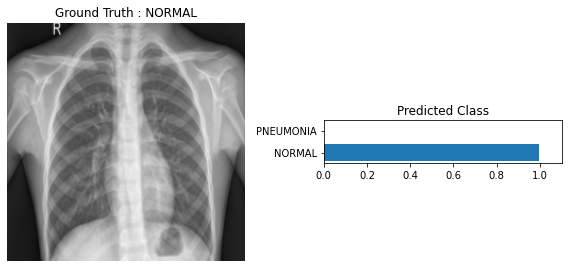

In [22]:
image,label = testset[0]

ps = torch.exp(model(image.to(device).unsqueeze(0)))
view_classify(image,ps,label)

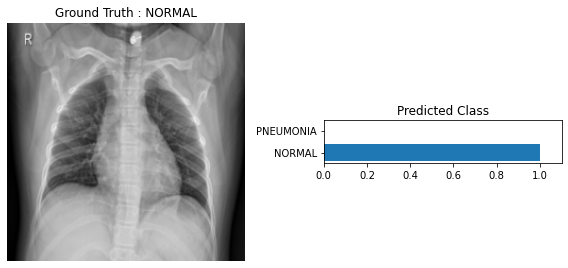

In [23]:
image,label = testset[36]

ps = torch.exp(model(image.to(device).unsqueeze(0)))
view_classify(image,ps,label)

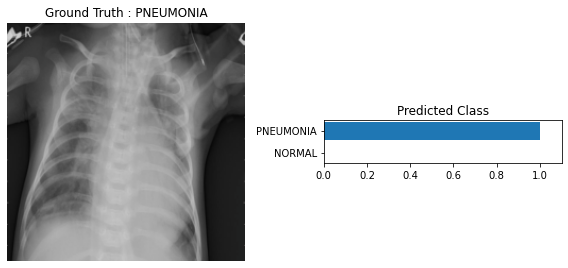

In [24]:
image,label = testset[330]

ps = torch.exp(model(image.to(device).unsqueeze(0)))
view_classify(image,ps,label)

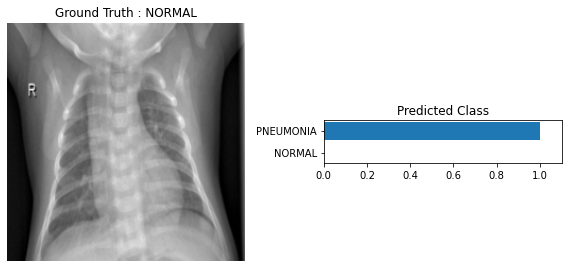

In [25]:
image,label = testset[49]

ps = torch.exp(model(image.to(device).unsqueeze(0)))
view_classify(image,ps,label)

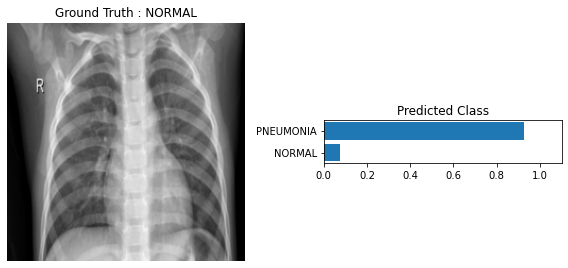

In [26]:
image,label = testset[56]

ps = torch.exp(model(image.to(device).unsqueeze(0)))
view_classify(image,ps,label)